Post-processing eccentricity posterior using [gw_eccentricity](https://github.com/vijayvarma392/gw_eccentricity)<br>
In this example, we use an MCMC parameter estimation result file from [Bilby](https://git.ligo.org/lscsoft/bilby)

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np

## Path to PE result file

In [2]:
result_file = "/Users/arif/Desktop/TEOB_chi0_9_ecc0_3_samples.hdf5"
injection_file = "/Users/arif/Desktop/injection.dat"

## Post-process the posterior file

For postprocessing Bilby result, we will use the derived class `PostProcessForBilby`

In [4]:
from gw_eccentricity.posterior.post_process_for_bilby import PostProcessForBilby

## create a datadict generator

In addition to the posterior result file, we need to provide a `data_dict_generator` function which given an index, representing a row in the posterior DataFrame, returns a data_dict that will be used to measure eccentricity using `gw_eccentricity.measure_eccentricity`

The intrinsic parameters (reference frequency, masses, spins, eccentricity and mean anomaly) should match the parameters used to generate the waveforms when using bilby

In [5]:
import sys
sys.path.append("/Users/arif/teobresums_reviewed/Python/")

In [6]:
from teob_backward_evolution import teob_data_dict_generator

Check that the data_dict generated using `dataDict_generator` makes sense

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

# Posteriors

Now we use the posterior result file and the `data_dict_generator` to instantiate an instance of  `PostProcessForBilby` class

In [8]:
egwBilby = PostProcessForBilby(result_file, data_dict_generator=teob_data_dict_generator,
                              data_dict_generator_kwargs={"ode_tmax": 1, "backwards": "yes"},
                              injection_file=injection_file)

18:44 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


# Looking at the original posteriors

In [9]:
egwBilby.get_posterior()

,H1_log_likelihood,H1_matched_filter_snr,H1_optimal_snr,L1_log_likelihood,L1_matched_filter_snr,L1_optimal_snr,L1_time,V1_log_likelihood,V1_matched_filter_snr,V1_optimal_snr,...,spin_2x,spin_2y,spin_2z,symmetric_mass_ratio,theta_jn,tilt_1,tilt_2,total_mass,total_mass_source,waveform_approximant
0,623.536988,35.393036- 1.832653j,36.320440,832.897895,40.886870+ 0.337570j,41.362264,2.022867,79.990989,12.783959+ 0.292588j,13.283787,...,0,0,0.840667,0.241917,0.254826,0.0,0.0,117.996238,87.927810,TEOBResumSDALI
1,623.737121,35.413042- 0.219257j,36.072400,834.313813,40.934172+ 0.893366j,40.930566,2.020499,78.126882,12.680335- 1.206002j,12.763677,...,0,0,0.884071,0.247294,0.799544,0.0,0.0,117.215195,91.807840,TEOBResumSDALI
2,625.263228,35.442456- 1.632387j,35.903969,829.859150,40.812956- 0.412181j,40.807886,2.023034,82.320345,12.970347+ 0.254119j,13.072128,...,0,0,0.756452,0.239020,0.189148,0.0,0.0,116.939708,87.103236,TEOBResumSDALI
3,623.660924,35.395494- 2.728341j,34.966475,833.187739,40.892780+ 2.002818j,40.065281,2.020089,81.065828,12.864432+ 0.454741j,12.946800,...,0,0,0.868357,0.247583,0.161180,0.0,0.0,117.422422,86.382175,TEOBResumSDALI
4,627.470438,35.506280+ 0.409910j,35.208147,830.505277,40.830341- 0.528652j,39.797103,2.020817,79.868891,12.782441+ 0.623043j,12.668456,...,0,0,0.812520,0.239390,0.230434,0.0,0.0,115.367024,86.073716,TEOBResumSDALI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12723,626.550917,35.499546+ 0.073499j,36.098698,845.009001,41.201355+ 0.036744j,40.760186,2.020851,82.309320,13.023293- 0.098106j,13.410467,...,0,0,0.885188,0.249987,0.951851,0.0,0.0,118.877416,95.101984,TEOBResumSDALI
12724,626.300630,35.496080- 0.830289j,35.969990,844.760389,41.198333+ 0.404540j,40.711227,2.020917,82.643707,13.059309- 0.070462j,13.374895,...,0,0,0.881033,0.249998,1.021669,0.0,0.0,118.442282,95.681426,TEOBResumSDALI
12725,626.957177,35.513985- 0.266306j,37.514769,844.633748,41.194731+ 0.495985j,42.412076,2.020852,82.200797,13.022836- 0.172487j,13.950999,...,0,0,0.888504,0.249980,1.004888,0.0,0.0,118.374764,96.129032,TEOBResumSDALI
12726,627.806113,35.532200+ 0.171292j,37.527899,844.150416,41.177941+ 1.132581j,42.491474,2.021137,82.267627,13.011608+ 0.770148j,14.006202,...,0,0,0.890064,0.249990,0.893409,0.0,0.0,118.771925,94.895787,TEOBResumSDALI


In [45]:
injection = egwBilby.get_injection()

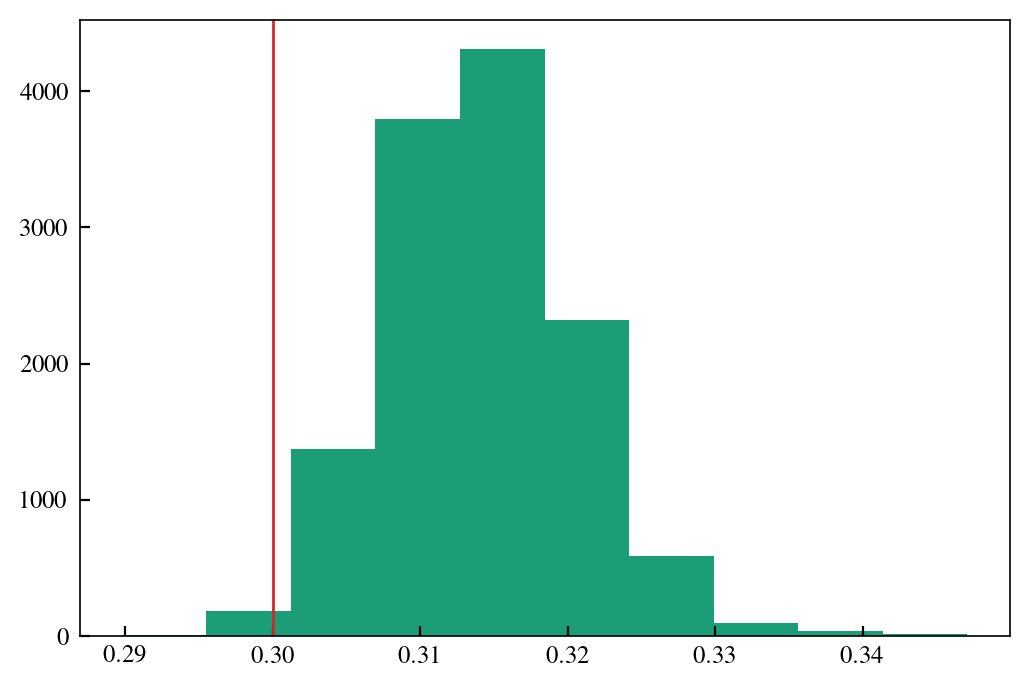

In [46]:
fig, ax = egwBilby.plot_eccentricity_posterior(**{"bins": 10})
ax.axvline(injection["eccentricity"], c="tab:red")

In [12]:
data_dict = egwBilby.get_injection_data_dict()

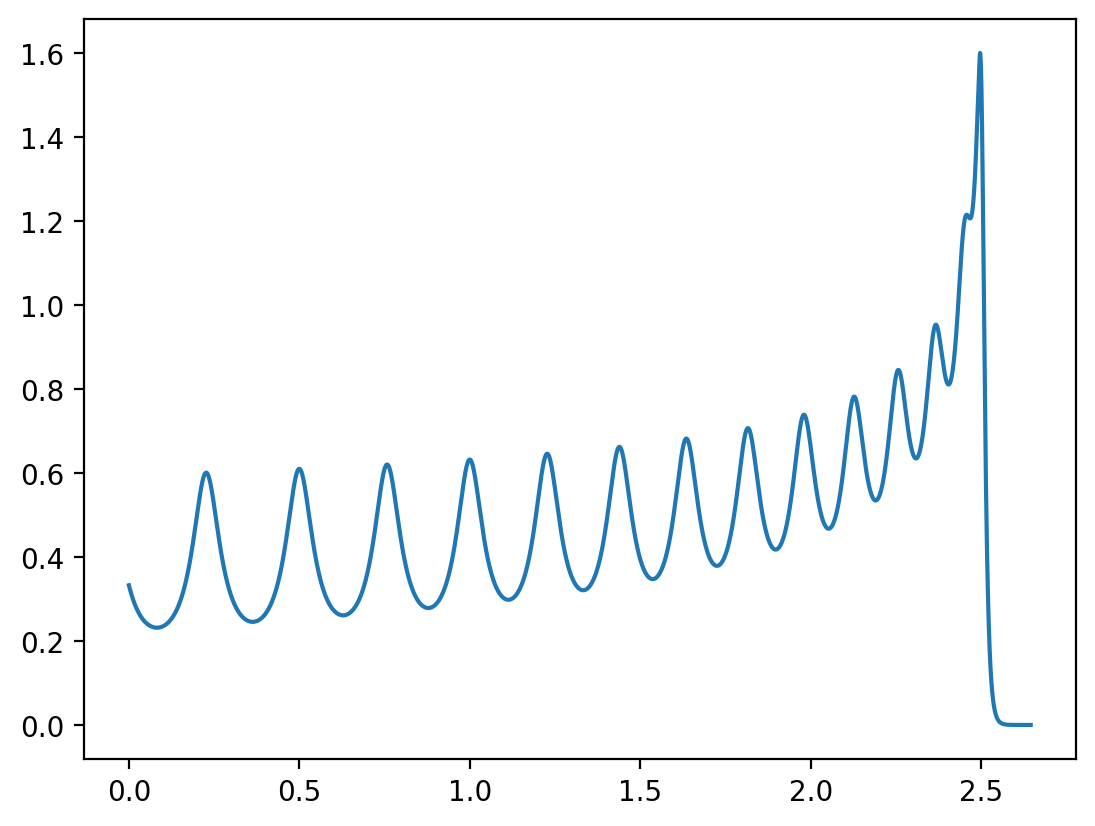

In [13]:
plt.plot(data_dict["t"], np.abs(data_dict["amplm"][(2, 2)]))

# Getting the best fref to use
Sometimes the chosen `fref`, the frequency where eccentricity and mean anomaly are to be measured could be outside the range where `egw` can be measured. Running the following code will give an idea of the `fref` bounds withing which majority of the samples can be post-processed.

This will also give an idea about how much backward evolving is required to get the orbit average frequency down to the desired `fref`.

In [16]:
from gw_eccentricity.posterior.post_process import get_fref_bounds_for_sample

In [32]:
# some settings to use
method = "AmplitudeFits"
gw_eccentricity_kwargs = {"extra_kwargs": {"omega_gw_extrema_interpolation_method": "spline"}}
samples = np.arange(0, 1000)
n_jobs = 6

We can check the range of frequencies where eccentricity and mean anomaly could be measured using the following method

In [33]:
params = egwBilby.posterior.iloc[0].to_dict()

In [34]:
get_fref_bounds_for_sample(
    params=params, 
    data_dict_generator=egwBilby.data_dict_generator, 
    data_dict_generator_kwargs=egwBilby.data_dict_generator_kwargs,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs
)

{'method': 'AmplitudeFits',
 'status': 'success',
 'fref_min': np.float64(8.502568615951818),
 'fref_max': np.float64(30.732467546647236),
 'params': {'H1_log_likelihood': 623.5369875098334,
  'H1_matched_filter_snr': np.complex128(35.39303572758314-1.832652685505252j),
  'H1_optimal_snr': 36.32044022415552,
  'L1_log_likelihood': 832.8978950522788,
  'L1_matched_filter_snr': np.complex128(40.886870487292214+0.33757000093877354j),
  'L1_optimal_snr': 41.36226439725715,
  'L1_time': 2.022867232481178,
  'V1_log_likelihood': 79.99098888699274,
  'V1_matched_filter_snr': np.complex128(12.783958777690742+0.2925876821974026j),
  'V1_optimal_snr': 13.283786977071745,
  'a_1': 0.892923508095561,
  'a_2': 0.8406665415823152,
  'chi_1': 0.892923508095561,
  'chi_1_in_plane': 0.0,
  'chi_2': 0.8406665415823152,
  'chi_2_in_plane': 0.0,
  'chi_eff': 0.8714930791712413,
  'chi_p': 0.0,
  'chirp_mass': 50.35800221829986,
  'chirp_mass_source': 37.5255088352051,
  'comoving_distance': 1388.614593484

Get the range of frequencies where we can measure egw and lgw. We take only a few samples to see this to save time.

In [35]:
egwBilby.get_fref_bounds(samples=samples,
                         method=method,
                         n_jobs=n_jobs,
                         gw_eccentricity_kwargs=gw_eccentricity_kwargs
                        )

Getting fref bounds: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:44<00:00, 22.54it/s]


{'fref_bounds': (np.float64(8.672119844770815),
  np.float64(29.736506966888665)),
 'success_percentage': 100.0,
 'failed_cases': []}

# Post-processing

We can measure eccentricity and mean anomaly for any sample using the following method

In [36]:
from gw_eccentricity.posterior.post_process import measure_eccentricity_for_sample

Post-process a given sample

In [37]:
fref = 10
measure_eccentricity_for_sample(
    params=params,
    data_dict_generator=egwBilby.data_dict_generator,
    data_dict_generator_kwargs=egwBilby.data_dict_generator_kwargs,
    fref=fref,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs)

{'method': 'AmplitudeFits',
 'fref': 10,
 'status': 'success',
 'eccentricity': np.float64(0.35274067986995084),
 'mean_anomaly': np.float64(4.6116213185060815),
 'params': {'H1_log_likelihood': 623.5369875098334,
  'H1_matched_filter_snr': np.complex128(35.39303572758314-1.832652685505252j),
  'H1_optimal_snr': 36.32044022415552,
  'L1_log_likelihood': 832.8978950522788,
  'L1_matched_filter_snr': np.complex128(40.886870487292214+0.33757000093877354j),
  'L1_optimal_snr': 41.36226439725715,
  'L1_time': 2.022867232481178,
  'V1_log_likelihood': 79.99098888699274,
  'V1_matched_filter_snr': np.complex128(12.783958777690742+0.2925876821974026j),
  'V1_optimal_snr': 13.283786977071745,
  'a_1': 0.892923508095561,
  'a_2': 0.8406665415823152,
  'chi_1': 0.892923508095561,
  'chi_1_in_plane': 0.0,
  'chi_2': 0.8406665415823152,
  'chi_2_in_plane': 0.0,
  'chi_eff': 0.8714930791712413,
  'chi_p': 0.0,
  'chirp_mass': 50.35800221829986,
  'chirp_mass_source': 37.5255088352051,
  'comoving_di

We can postprocess a subset of the smaples or all the samples using the following method

In [38]:
import time

In [39]:
fref = 10
t_start = time.perf_counter()
egwBilby.post_process(fref=fref, samples=samples,
                      method=method,
                      gw_eccentricity_kwargs=gw_eccentricity_kwargs,
                      n_jobs=n_jobs)
t_stop = time.perf_counter()

Post-processing samples: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:47<00:00, 21.14it/s]


In [40]:
print(f"Took {t_stop - t_start} seconds for {len(samples)} samples on {n_jobs} cores.")

Took 47.95312083300087 seconds for 1000 samples on 6 cores.


## View the results

In [41]:
egwBilby.post_process_result[:5]

[{'method': 'AmplitudeFits',
  'fref': 10,
  'status': 'success',
  'eccentricity': np.float64(0.35274067986995084),
  'mean_anomaly': np.float64(4.6116213185060815),
  'params': {'H1_log_likelihood': 623.5369875098334,
   'H1_matched_filter_snr': (35.39303572758314-1.832652685505252j),
   'H1_optimal_snr': 36.32044022415552,
   'L1_log_likelihood': 832.8978950522788,
   'L1_matched_filter_snr': (40.886870487292214+0.33757000093877354j),
   'L1_optimal_snr': 41.36226439725715,
   'L1_time': 2.022867232481178,
   'V1_log_likelihood': 79.99098888699274,
   'V1_matched_filter_snr': (12.783958777690742+0.2925876821974026j),
   'V1_optimal_snr': 13.283786977071745,
   'a_1': 0.892923508095561,
   'a_2': 0.8406665415823152,
   'chi_1': 0.892923508095561,
   'chi_1_in_plane': 0.0,
   'chi_2': 0.8406665415823152,
   'chi_2_in_plane': 0.0,
   'chi_eff': 0.8714930791712413,
   'chi_p': 0.0,
   'chirp_mass': 50.35800221829986,
   'chirp_mass_source': 37.5255088352051,
   'comoving_distance': 1388

In [42]:
egw_inj, mean_ano_inj = egwBilby.get_injection_eccentricity(
    fref=fref,
    method=method,
    gw_eccentricity_kwargs=gw_eccentricity_kwargs,
    # debug=True
)

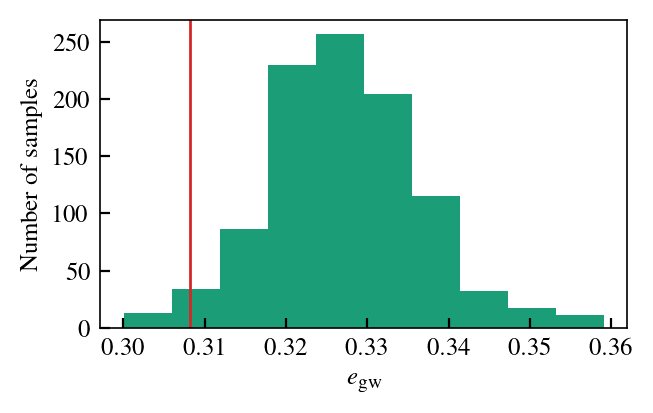

In [43]:
fig, ax = egwBilby.plot_egw_posterior(usetex=True, style="APS")
ax.axvline(egw_inj, c="tab:red")

## Get a summary of the post-process, like how many cases were successfully post-processed

In [44]:
egwBilby.post_process_summary()

{'total_samples': 1000,
 'success_percentage': 100.0,
 'fref': 10,
 'method': 'AmplitudeFits',
 'eccentricity': [np.float64(0.35274067986995084),
  np.float64(0.3493114151362695),
  np.float64(0.35903151990418425),
  np.float64(0.3300606690705985),
  np.float64(0.35618468097422373),
  np.float64(0.35773681179057837),
  np.float64(0.35788833018137256),
  np.float64(0.3519526926697223),
  np.float64(0.35333804281347536),
  np.float64(0.35533718776966594),
  np.float64(0.3333132076683235),
  np.float64(0.33585428718991384),
  np.float64(0.35174674275015483),
  np.float64(0.3219714834642732),
  np.float64(0.34082714437131556),
  np.float64(0.35714225031344127),
  np.float64(0.35322762036740785),
  np.float64(0.34663703430044424),
  np.float64(0.3364287550870688),
  np.float64(0.33269433978426943),
  np.float64(0.3256689725270471),
  np.float64(0.31652311797757815),
  np.float64(0.3355569249662007),
  np.float64(0.33040579707691764),
  np.float64(0.34260343167542984),
  np.float64(0.3509156